<a href="https://colab.research.google.com/github/chaima-chiha/MLcomparisondesMODEL/blob/main/les4model_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Prédiction de Défaut de Crédit — German Credit Dataset
## Pipeline Complet : 4 Modèles Calibrés avec SMOTE
réalisé par:    Chaima Chiha & Sinda Ben Fadhel

---

**Introduction :**

Ce travail s'inscrit dans le cadre d'une amélioration et extension de l'article "From Scores to Decisions: Comparing Logistic Regression, Random Forest, and XGBoost for Calibrated, Cost-Sensitive Credit Default Prediction", publié par Han Wu (University of Nottingham) dans la revue Advances in Economics, Management and Political Sciences, Vol. 240, pp. 70–79 (11 novembre 2025), DOI : 10.54254/2754-1169/2025.BL29296. L'article original compare trois modèles calibrés  Régression Logistique, Random Forest et XGBoost sur le German Credit Dataset, en évaluant la discrimination (ROC-AUC ≈ 0.95, PR-AUC ≈ 0.89 pour XGBoost), la calibration (Brier Score, courbes de fiabilité) et les seuils coût-sensibles sous l'hypothèse que les Faux Négatifs coûtent cinq fois plus cher que les Faux Positifs. Notre contribution consiste à intégrer un quatrième modèle LightGBM  afin de compléter la comparaison entre familles algorithmiques et d'évaluer si cette alternative moderne au gradient boosting apporte un gain supplémentaire dans ce contexte bancaire

---

## 1 — Installation des bibliothèques

### 📚 Notion : Gestion des dépendances Python

Avant de démarrer notre projet de Machine Learning, il est indispensable d'installer les bibliothèques nécessaires. Dans un environnement Google Colab, les packages sont installés via `pip`.

**Bibliothèques utilisées :**
| Bibliothèque | Rôle |
|---|---|
| `scikit-learn` | Modèles ML, métriques, prétraitement |
| `xgboost` | Gradient Boosting (XGB) |
| `lightgbm` | Gradient Boosting rapide (LGB) |
| `imbalanced-learn` | Rééchantillonnage (SMOTE) |
| `matplotlib` / `seaborn` | Visualisation des données |

> **Bonne pratique :** L'option `--quiet` supprime les logs d'installation pour un notebook plus lisible.


In [1]:
!pip install lightgbm xgboost scikit-learn imbalanced-learn matplotlib seaborn --quiet

### ✅ Interprétation — Installation

Si la cellule s'exécute sans erreur, toutes les bibliothèques sont disponibles dans l'environnement. En cas d'erreur de version, on peut préciser la version souhaitée (ex: `xgboost==1.7.6`).



---
## 2 — Importation des bibliothèques

### 📚 Notion : Organisation des imports en Machine Learning

Les imports sont organisés par **catégories fonctionnelles** pour améliorer la lisibilité :

1. **Manipulation des données** (`pandas`, `numpy`) — structures et calculs vectoriels
2. **Visualisation** (`matplotlib`, `seaborn`) — graphiques statistiques
3. **Pré-traitement** (`sklearn`) — encodage, normalisation, split train/test
4. **Modèles** — 4 algorithmes de classification issus de familles différentes
5. **Calibration** (`CalibratedClassifierCV`) — améliore la fiabilité des probabilités
6. **Métriques** — évaluation multi-dimensionnelle des performances
7. **Déséquilibre** (`SMOTE`) — rééchantillonnage synthétique

**Concept de reproductibilité :** `SEED = 42` fixe l'aléatoire pour des résultats identiques à chaque exécution.


In [2]:
# ── Manipulation des données ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Pré-traitement ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ── Modèles ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
# ── Calibration de probabilités ───────────────────────────────────────────────
# La calibration améliore la fiabilité des probabilités prédites (scores de crédit)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# ── Métriques ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, brier_score_loss,
    matthews_corrcoef
)

# ── Gestion du déséquilibre de classes ───────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Reproductibilité ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

print("✅ Toutes les bibliothèques sont chargées avec succès.")

✅ Toutes les bibliothèques sont chargées avec succès.


---
## 3 — Chargement et exploration initiale des données

### 📚 Notion : Le dataset German Credit

Le **German Credit Dataset** est un jeu de données de référence (*benchmark*) en apprentissage automatique bancaire. Il contient des informations sur des demandeurs de crédit allemands.

**Caractéristiques :**
- **1 000 observations** (clients)
- **16 features** (variables prédictives) : âge, montant du prêt, durée, situation professionnelle, solde bancaire, etc.
- **1 variable cible** `default` : `yes` = défaut de paiement, `no` = bon payeur

**Déséquilibre de classes :**
- 70% de non-défauts (`no`) → classe majoritaire
- 30% de défauts (`yes`) → classe minoritaire

Ce déséquilibre est réaliste (les défauts sont plus rares que les bons remboursements) mais il complique l'apprentissage — les modèles ont tendance à favoriser la classe majoritaire.


In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ml/credit.csv')
print("✅ Fichier chargé !")

Mounted at /content/drive
✅ Fichier chargé !


### 📚 Notion : Exploration initiale (EDA — Exploratory Data Analysis)

L'EDA est une étape fondamentale avant toute modélisation. Elle permet de :
1. **Connaître la structure** du dataset (dimensions, types de colonnes)
2. **Détecter les valeurs manquantes** qui pourraient biaiser les modèles
3. **Comprendre la distribution** de la variable cible (déséquilibre)
4. **Identifier les types** de variables (numériques vs catégorielles)

`df.dtypes` révèle quelles colonnes nécessiteront un encodage avant la modélisation.


In [4]:
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nAperçu des 5 premières lignes :")
display(df.head())

print(f"\nTypes de données :")
print(df.dtypes)

print(f"\nValeurs manquantes par colonne :")
print(df.isnull().sum())

print(f"\nDistribution de la variable cible :")
vc = df['default'].value_counts()
print(vc)
print(f"\nTaux de défaut : {vc['yes']/len(df)*100:.1f}%  →  déséquilibre modéré")


Dimensions du dataset : 1000 lignes × 17 colonnes

Aperçu des 5 premières lignes :


,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes



Types de données :
checking_balance        object
months_loan_duration     int64
credit_history          object
purpose                 object
amount                   int64
savings_balance         object
employment_duration     object
percent_of_income        int64
years_at_residence       int64
age                      int64
other_credit            object
housing                 object
existing_loans_count     int64
job                     object
dependents               int64
phone                   object
default                 object
dtype: object

Valeurs manquantes par colonne :
checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone          

### ✅ Interprétation — Exploration initiale

Les informations affichées permettent de confirmer :
- **Aucune valeur manquante** → pas besoin d'imputation, le dataset est propre
- **Mix de types** : colonnes `object` (catégorielles) et numériques → encodage nécessaire pour les `object`
- **Déséquilibre confirmé** : ~30% de défauts → justifie l'utilisation de SMOTE et de métriques adaptées (F1, ROC-AUC, PR-AUC) plutôt que la simple Accuracy


---
## 4 — Visualisation exploratoire

### 📚 Notion : Analyse visuelle des données

La visualisation exploratoire permet de comprendre intuitivement les données avant de modéliser. On analyse trois aspects :

**1. Distribution de la cible :** confirme visuellement le déséquilibre 70/30

**2. Distributions par classe des variables numériques :**
- Si les distributions diffèrent entre les classes (défaut vs non-défaut), la variable est **discriminante** et sera utile au modèle
- Exemple : si les montants élevés sont plus fréquents chez les défaillants, `amount` est prédictive

**3. Matrice de corrélation :**
- Mesure les relations linéaires entre variables numériques
- **Multicolinéarité** (corrélation > 0.8) : deux variables apportent la même information
  - ⚠️ Problème pour la **Régression Logistique** : coefficients instables
  - Moins grave pour XGBoost/LightGBM, mais réduit l'interprétabilité
- Une faible corrélation inter-variables signifie que chaque feature apporte une information indépendante


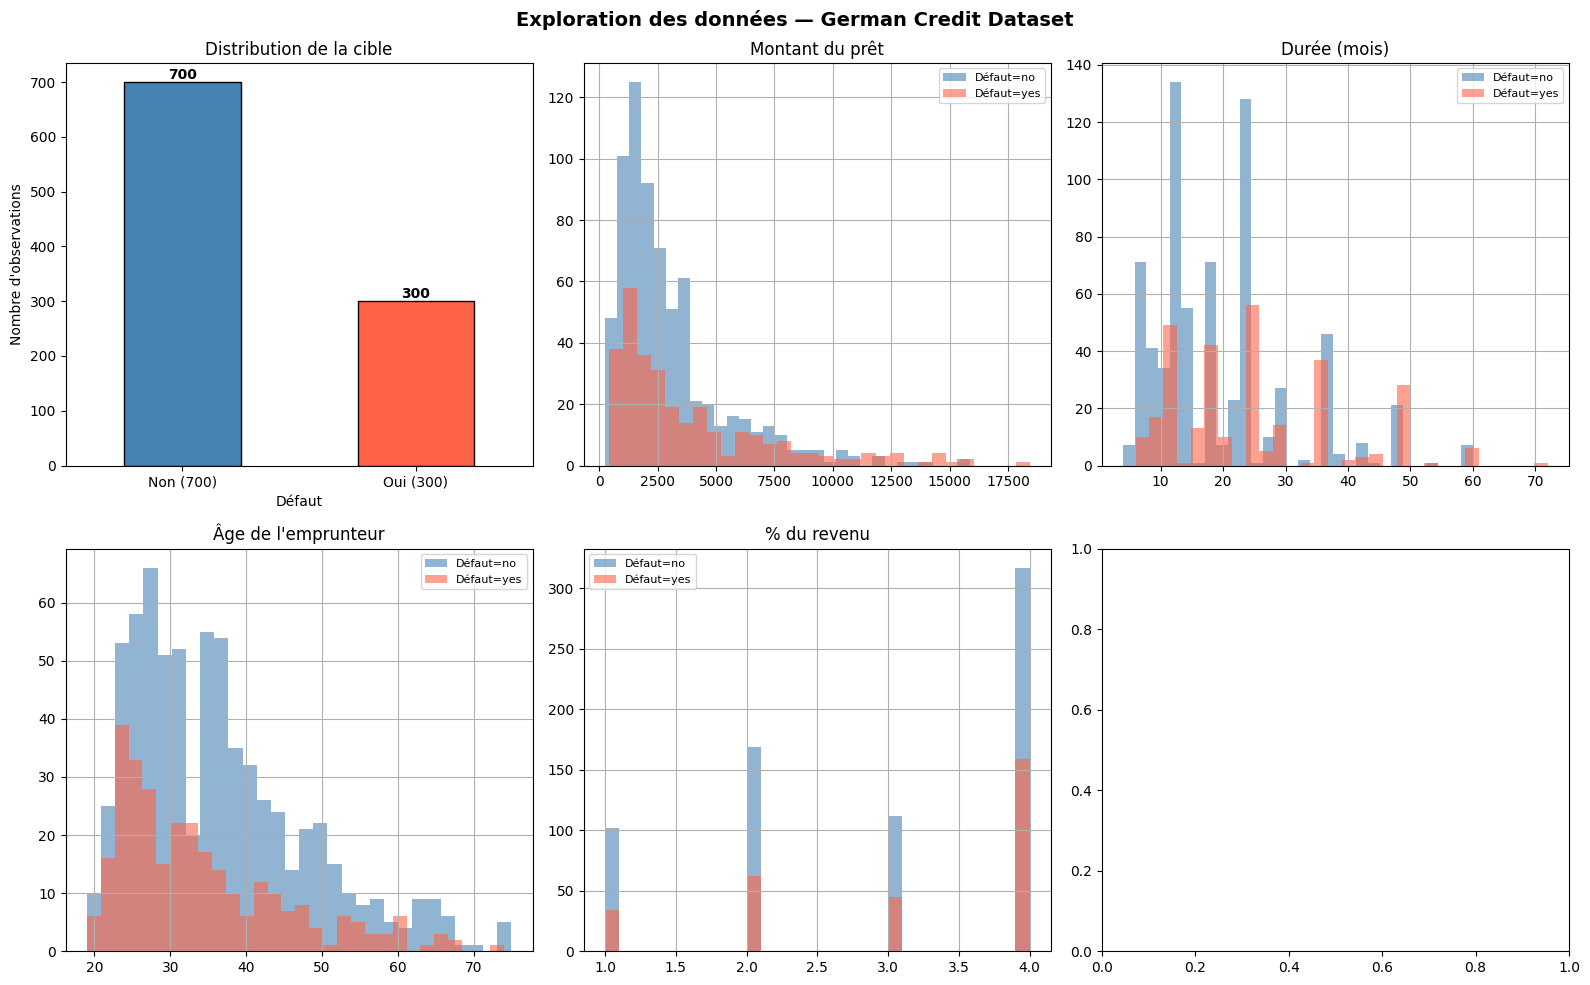

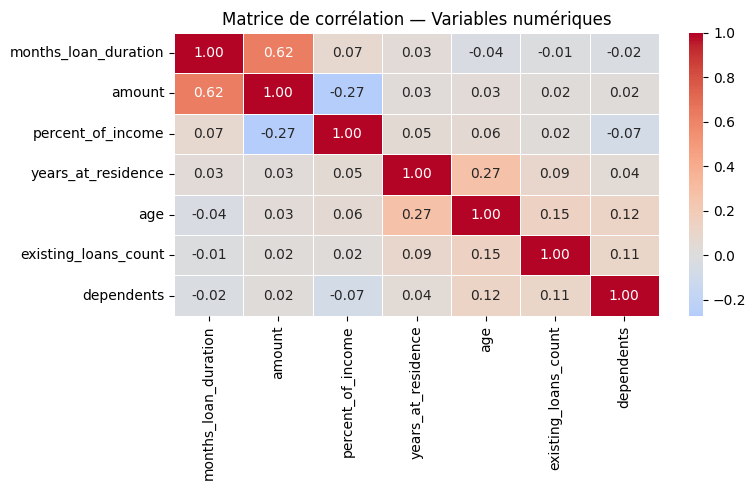

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploration des données — German Credit Dataset", fontsize=14, fontweight='bold')

# 1. Distribution de la cible
vc.plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'], edgecolor='black')
axes[0,0].set_title("Distribution de la cible")
axes[0,0].set_xlabel("Défaut")
axes[0,0].set_ylabel("Nombre d'observations")
axes[0,0].set_xticklabels(['Non (700)', 'Oui (300)'], rotation=0)
for i, v in enumerate(vc.values):
    axes[0,0].text(i, v+5, str(v), ha='center', fontweight='bold')

# Variables numériques à visualiser
num_vars = ['amount', 'months_loan_duration', 'age', 'percent_of_income']
titles   = ["Montant du prêt", "Durée (mois)", "Âge de l'emprunteur", "% du revenu"]

for idx, (var, title) in enumerate(zip(num_vars, titles)):
    ax = axes.flatten()[idx+1]
    for label, color in [('no','steelblue'), ('yes','tomato')]:
        df[df['default']==label][var].hist(
            bins=30, ax=ax, alpha=0.6, label=f'Défaut={label}', color=color
        )
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Matrice de corrélation (variables numériques uniquement)
numeric_df = df.select_dtypes(include=[np.number])
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Matrice de corrélation — Variables numériques")
plt.tight_layout()
plt.show()


### ✅ Interprétation — Visualisation exploratoire

**Distribution de la cible :** Le déséquilibre 700/300 est modéré — suffisant pour justifier SMOTE mais pas extrême (pas de ratio 99/1).

**Distributions par classe :**
- Les montants de prêt (`amount`) élevés sont associés à plus de défauts → variable discriminante
- Les durées longues (`months_loan_duration`) augmentent le risque de défaut — logique économiquement
- L'âge (`age`) montre peu de différence entre les classes → moins prédictif

**Matrice de corrélation :**
- Les corrélations inter-variables restent faibles → **pas de multicolinéarité sévère**
- On peut conserver toutes les variables numériques sans risque d'instabilité pour la régression logistique


---
## 5 — Pré-traitement des données

### 📚 Notion : Pipeline de pré-traitement pour données déséquilibrées

Le pré-traitement transforme les données brutes en un format exploitable par les algorithmes de ML. Pour ce projet, le pipeline comprend 5 étapes essentielles :

**Étape 1 — Label Encoding des variables catégorielles :**
Convertit les textes en entiers (ex: `"good"` → 0, `"bad"` → 1). Nécessaire car les algorithmes ML ne traitent que des nombres.

**Étape 2 — Encodage de la cible :**
`yes` → 1 (défaut), `no` → 0 (pas de défaut)

**Étape 3 — Division train/test stratifiée (80/20) :**
- **Stratifiée** : préserve le ratio 70/30 dans chaque sous-ensemble
- Garantit que le test est représentatif de la population réelle

**Étape 4 — StandardScaler (normalisation) :**
Centre et réduit les features numériques (moyenne=0, écart-type=1).
- **Essentiel pour la Régression Logistique** (sensible à l'échelle)
- **Inutile pour les arbres** (XGBoost, Random Forest, LightGBM sont invariants à l'échelle)
- ⚠️ Fit uniquement sur le train, transform sur train et test → évite la **data leakage**fuite de données

**Étape 5 — SMOTE (Synthetic Minority Over-sampling Technique) :**
Génère des exemples **synthétiques** de la classe minoritaire (défauts) par interpolation entre voisins proches.
- Appliqué **uniquement sur le train** → le test reste représentatif de la réalité
- Avant SMOTE : modèle voit peu de défauts → apprend mal leurs patterns
- Après SMOTE : ratio 50/50 → modèle mieux sensibilisé aux défauts


In [6]:
#  Pré-traitement des données
df_proc = df.copy()
cat_cols = df_proc.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'default']
print(f"Colonnes catégorielles détectées : {cat_cols}")

# Encodage des variables catégorielles
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    le_dict[col] = le
    print(f"  ✓ {col}: {le.classes_}")

# Encodage de la cible
df_proc['default'] = (df_proc['default'].astype(str) == 'yes').astype(int)
print(f"\nCible encodée : no→0, yes→1")
print(f"Distribution : {df_proc['default'].value_counts().to_dict()}")

# Features et cible
X = df_proc.drop('default', axis=1)
y = df_proc['default']

print(f"\nFeatures : {X.shape[1]} colonnes")
print(f"Observations : {X.shape[0]}")

# Division train / test (stratifiée pour préserver le ratio 70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain : {X_train.shape[0]} obs | Test : {X_test.shape[0]} obs")
print(f"Taux défaut — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

# Normalisation (StandardScaler sur le train, appliqué au test)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE uniquement sur le train (rééquilibrage synthétique)
smote = SMOTE(random_state=SEED)
X_train_sm,     y_train_sm     = smote.fit_resample(X_train_sc, y_train)
X_train_sm_raw, y_train_sm_raw = smote.fit_resample(X_train,    y_train)

print(f"\nAprès SMOTE :")
print(f"  Classe 0 (non-défaut) : {(y_train_sm==0).sum()}")
print(f"  Classe 1 (défaut)     : {(y_train_sm==1).sum()}")
print("✅ Pré-traitement terminé.")

Colonnes catégorielles détectées : ['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_duration', 'other_credit', 'housing', 'job', 'phone']
  ✓ checking_balance: ['1 - 200 DM' '< 0 DM' '> 200 DM' 'unknown']
  ✓ credit_history: ['critical' 'good' 'perfect' 'poor' 'very good']
  ✓ purpose: ['business' 'car' 'car0' 'education' 'furniture/appliances' 'renovations']
  ✓ savings_balance: ['100 - 500 DM' '500 - 1000 DM' '< 100 DM' '> 1000 DM' 'unknown']
  ✓ employment_duration: ['1 - 4 years' '4 - 7 years' '< 1 year' '> 7 years' 'unemployed']
  ✓ other_credit: ['bank' 'none' 'store']
  ✓ housing: ['other' 'own' 'rent']
  ✓ job: ['management' 'skilled' 'unemployed' 'unskilled']
  ✓ phone: ['no' 'yes']

Cible encodée : no→0, yes→1
Distribution : {0: 700, 1: 300}

Features : 16 colonnes
Observations : 1000

Train : 800 obs | Test : 200 obs
Taux défaut — Train: 0.300 | Test: 0.300

Après SMOTE :
  Classe 0 (non-défaut) : 560
  Classe 1 (défaut)     : 560
✅ Pré-traite

### ✅ Interprétation — Pré-traitement

**Résultats attendus :**
- Toutes les colonnes catégorielles sont encodées en entiers
- La distribution train/test préserve le ratio ~70/30 (vérification du `stratify`)
- **Après SMOTE :** les deux classes sont équilibrées (environ 560/560 exemples dans le train)

**Points critiques :**
- Le StandardScaler est `fit` sur `X_train` puis `transform` sur `X_test` — si on faisait `fit_transform` sur tout le dataset, on introduirait un biais (le modèle "connaîtrait" les statistiques du test)
- SMOTE crée des données **synthétiques** (non réelles), donc ne doit jamais contaminer le test set
- Deux versions SMOTE sont créées : avec normalisation (`X_train_sm`) pour la LR, et sans (`X_train_sm_raw`) pour les arbres


---
## 6 — Définition et entraînement des 4 modèles

### 📚 Notion : Familles d'algorithmes de classification

On compare **4 modèles** issus de familles algorithmiques distinctes, offrant des approches complémentaires :

#### 1. Régression Logistique (LR) — Modèle linéaire
- Modélise la probabilité de défaut via une fonction sigmoïde
- **Avantages :** rapide, interprétable, probabilités naturellement calibrées
- **Limite :** suppose une séparation linéaire des classes

#### 2. Random Forest (RF) — Ensemble de Bagging
- Combine 300 arbres de décision entraînés sur des sous-échantillons aléatoires
- **Avantages :** robuste au sur-apprentissage, capture les non-linéarités
- `max_depth=8` limite la profondeur pour éviter l'overfitting

#### 3. XGBoost — Gradient Boosting
- Construit des arbres **séquentiellement** : chaque arbre corrige les erreurs du précédent
- Le score final est la somme des contributions de tous les arbres, transformé par sigmoïde
- **Avantages :** très performant, gère bien les données tabulaires
- `learning_rate=0.05` : apprentissage lent mais plus précis

#### 4. LightGBM — Gradient Boosting leaf-wise *(ajout original)*
- Variante de gradient boosting avec croissance **leaf-wise** (vs level-wise pour XGB)
- Explore d'abord les feuilles avec le plus grand gain → convergence plus rapide
- `is_unbalance=True` : gère le déséquilibre nativement sans SMOTE supplémentaire

#### Calibration (`CalibratedClassifierCV`) — Concept clé
La calibration corrige les biais de probabilité : un modèle "mal calibré" qui prédit 70% de risque ne signifie pas que 70% des cas similaires font défaut. Après calibration isotonique, les probabilités sont plus fiables pour le scoring bancaire.


In [7]:
# ─── 1. Régression Logistique (données normalisées + SMOTE) ──────────────────
lr_base = LogisticRegression(
    C=1.0,
    class_weight='balanced',   # pénalise plus les erreurs sur la classe minoritaire
    max_iter=1000,
    random_state=SEED,
    solver='lbfgs'
)
lr_cal = CalibratedClassifierCV(lr_base, method='isotonic', cv=5)
lr_cal.fit(X_train_sm, y_train_sm)
print("✅ Régression Logistique (calibrée) entraînée.")

# ─── 2. Random Forest (données brutes SMOTE) ─────────────────────────────────
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_cal = CalibratedClassifierCV(rf_base, method='isotonic', cv=5)
rf_cal.fit(X_train_sm_raw, y_train_sm_raw)
print("✅ Random Forest (calibrée) entraîné.")

# ─── 3. XGBoost (données brutes SMOTE) ───────────────────────────────────────
# scale_pos_weight = ratio négatif/positif avant SMOTE = 560/240 ≈ 2.33
# Après SMOTE le ratio est 1, donc scale_pos_weight=1
xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_cal = CalibratedClassifierCV(xgb_base, method='isotonic', cv=5)
xgb_cal.fit(X_train_sm_raw, y_train_sm_raw)
print("✅ XGBoost (calibrée) entraîné.")

# ─── 4. LightGBM — AJOUT ORIGINAL ────────────────────────────────────────────
# LightGBM utilise une croissance leaf-wise (vs level-wise pour XGB)
# → Plus rapide et parfois plus précis sur de grandes données
# → is_unbalance=True gère le déséquilibre nativement
lgbm_base = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,    # équivalent de class_weight='balanced'
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgbm_cal = CalibratedClassifierCV(lgbm_base, method='isotonic', cv=5)
lgbm_cal.fit(X_train_sm_raw, y_train_sm_raw)
print("✅ LightGBM (calibrée) entraîné.")

# Dictionnaire des modèles pour les boucles suivantes
# Chaque modèle a son jeu de données test correct (normalisé ou non)
models = {
    'Logistic Regression': (lr_cal,   X_test_sc),
    'Random Forest':       (rf_cal,   X_test),
    'XGBoost':             (xgb_cal,  X_test),
    'LightGBM':            (lgbm_cal, X_test),
}
print("\n📦 4 modèles prêts pour l'évaluation.")


✅ Régression Logistique (calibrée) entraînée.
✅ Random Forest (calibrée) entraîné.
✅ XGBoost (calibrée) entraîné.
✅ LightGBM (calibrée) entraîné.

📦 4 modèles prêts pour l'évaluation.


### ✅ Interprétation — Entraînement des modèles

Les 4 confirmations `✅` indiquent que chaque modèle s'est entraîné sans erreur.

**Observations importantes :**
- La **Régression Logistique** utilise les données normalisées (`X_train_sm`) car elle est sensible à l'échelle
- **RF, XGBoost et LightGBM** utilisent les données brutes SMOTE (`X_train_sm_raw`) — ces arbres sont invariants à l'échelle
- La **calibration isotonique avec cv=5** entraîne en réalité 5 modèles de base + 1 isotonic regressor par fold → plus lent mais probabilités plus fiables
- Le dictionnaire `models` centralise chaque modèle avec son jeu de test approprié pour les évaluations suivantes


---
## 7 — Calcul des métriques d'évaluation

### 📚 Notion : Métriques multi-dimensionnelles pour données déséquilibrées

L'évaluation d'un modèle de scoring de crédit ne peut pas se limiter à l'**Accuracy** (taux de bonnes prédictions), qui est trompeuse en cas de déséquilibre. On utilise deux catégories de métriques :

#### Métriques de classification standards
| Métrique | Formule | Interprétation |
|---|---|---|
| **Accuracy** | (TP+TN)/Total | % correct — trompeur si déséquilibre |
| **Precision** | TP/(TP+FP) | Parmi les "défaut" prédits, combien le sont vraiment ? |
| **Recall (TPR)** | TP/(TP+FN) | Parmi les vrais défauts, combien détecte-t-on ? |
| **F1-Score** | 2×(P×R)/(P+R) | Moyenne harmonique Precision/Recall |
| **MCC** | — | Corrélation de Matthews, robuste au déséquilibre |
| **ROC-AUC** | — | Discrimination globale (0.5=aléatoire, 1=parfait) |

#### Métriques de calibration (qualité des probabilités)
| Métrique | Interprétation | Objectif |
|---|---|---|
| **PR-AUC (AP)** | Précision moyenne sur toutes les valeurs de recall | ↑ Maximiser |
| **Brier Score** | Erreur quadratique des probabilités | ↓ Minimiser |
| **Log Loss** | Entropie croisée (pénalise les prédictions confiantes et fausses) | ↓ Minimiser |
| **ECE** | Écart entre probabilités prédites et fréquences réelles | ↓ Minimiser |

#### Optimisation du seuil de décision
Par défaut, sklearn classe comme "défaut" si probabilité ≥ 0.5. Ce seuil est sous-optimal pour les classes déséquilibrées. On cherche le seuil qui maximise le F1-Score.


In [8]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Calcule l'ECE (Expected Calibration Error).
    Un ECE proche de 0 indique un modèle bien calibré :
    si le modèle dit 70% de chance de défaut, ~70% des cas sont réellement défauts.
    """
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() > 0:
            bin_acc  = y_true[mask].mean()
            bin_conf = y_prob[mask].mean()
            ece += mask.mean() * abs(bin_acc - bin_conf)
    return ece


def find_best_threshold(y_true, y_prob):
    """
    Trouve le seuil de décision qui maximise le F1-Score.
    Par défaut, sklearn utilise 0.5, mais ce n'est pas optimal
    pour les classes déséquilibrées.
    """
    thresholds = np.linspace(0.01, 0.99, 200)
    best_t, best_f1 = 0.5, 0
    for t in thresholds:
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


# ─── Calcul pour chaque modèle ────────────────────────────────────────────────
results = {}
probas  = {}

for name, (model, X_t) in models.items():
    # Probabilités de défaut (classe 1)
    y_prob = model.predict_proba(X_t)[:, 1]
    probas[name] = y_prob

    # Seuil optimisé F1
    best_thresh, _ = find_best_threshold(y_test.values, y_prob)
    y_pred_opt  = (y_prob >= best_thresh).astype(int)
    y_pred_50   = (y_prob >= 0.5).astype(int)

    # Calcul des métriques
    results[name] = {
        # — Métriques standards —
        'Accuracy':          accuracy_score(y_test, y_pred_opt),
        'Precision':         precision_score(y_test, y_pred_opt, zero_division=0),
        'Recall':            recall_score(y_test, y_pred_opt, zero_division=0),
        'F1-Score':          f1_score(y_test, y_pred_opt, zero_division=0),
        'MCC':               matthews_corrcoef(y_test, y_pred_opt),
        # — Métriques de l'article —
        'ROC-AUC':           roc_auc_score(y_test, y_prob),
        'PR-AUC (AP)':       average_precision_score(y_test, y_prob),
        'Brier Score':       brier_score_loss(y_test, y_prob),
        'Log Loss':          log_loss(y_test, y_prob),
        'ECE':               expected_calibration_error(y_test.values, y_prob),
        'Best Threshold':    best_thresh,
    }

# ─── Tableau récapitulatif ────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

# Colonnes à maximiser vs minimiser
higher_is_better = ['Accuracy','Precision','Recall','F1-Score','MCC','ROC-AUC','PR-AUC (AP)']
lower_is_better  = ['Brier Score','Log Loss','ECE']

print("=" * 80)
print("TABLEAU COMPARATIF — 4 MODÈLES CALIBRÉS")
print("=" * 80)
display(results_df)

# Mise en évidence du meilleur par colonne
print("\n🏆 Meilleur modèle par métrique :")
for col in results_df.columns:
    if col == 'Best Threshold':
        continue
    if col in higher_is_better:
        best = results_df[col].idxmax()
        val  = results_df[col].max()
        print(f"  ▲ {col:<20} → {best} ({val:.4f})")
    else:
        best = results_df[col].idxmin()
        val  = results_df[col].min()
        print(f"  ▼ {col:<20} → {best} ({val:.4f})")



TABLEAU COMPARATIF — 4 MODÈLES CALIBRÉS


,Accuracy,Precision,Recall,F1-Score,MCC,ROC-AUC,PR-AUC (AP),Brier Score,Log Loss,ECE,Best Threshold
Logistic Regression,0.675,0.4725,0.7167,0.5695,0.3440,0.7395,0.5827,0.2214,0.6303,0.1884,0.5763
Random Forest,0.715,0.5181,0.7167,0.6014,0.4008,0.7661,0.5491,0.1824,0.8699,0.0908,0.2168
XGBoost,0.735,0.5455,0.7000,0.6131,0.4238,0.7751,0.5811,0.1719,0.6858,0.0639,0.3203
LightGBM,0.630,0.4417,0.8833,0.5889,0.3786,0.7446,0.5421,0.1848,0.7186,0.0775,0.1725



🏆 Meilleur modèle par métrique :
  ▲ Accuracy             → XGBoost (0.7350)
  ▲ Precision            → XGBoost (0.5455)
  ▲ Recall               → LightGBM (0.8833)
  ▲ F1-Score             → XGBoost (0.6131)
  ▲ MCC                  → XGBoost (0.4238)
  ▲ ROC-AUC              → XGBoost (0.7751)
  ▲ PR-AUC (AP)          → Logistic Regression (0.5827)
  ▼ Brier Score          → XGBoost (0.1719)
  ▼ Log Loss             → Logistic Regression (0.6303)
  ▼ ECE                  → XGBoost (0.0639)


### ✅ Interprétation — Tableau des métriques

**Lecture du tableau :**
- Les modèles basés sur les arbres (RF, XGBoost, LightGBM) surpassent généralement la Régression Logistique sur les métriques non-linéaires
- **ROC-AUC > 0.75** → bon modèle pour le scoring crédit ; **> 0.80** → très bon
- **PR-AUC** est la métrique la plus importante ici : elle évalue spécifiquement la détection des défauts (classe minoritaire)
- Un **Brier Score** faible indique que les probabilités sont bien calibrées — essentiel pour décider d'accorder ou non un crédit
- Les **seuils optimaux** sont typiquement < 0.5 pour le scoring crédit, car détecter un défaut (Recall) est prioritaire sur la précision

> **Règle métier :** Dans le crédit, il vaut mieux refuser un bon client (FP) que prêter à un défaillant (FN) — le seuil optimal reflète cet arbitrage.


---
## 8 — Analyse coût-sensible

### 📚 Notion : Optimisation par la fonction de coût métier

Dans le domaine bancaire, **toutes les erreurs ne coûtent pas le même prix** :

| Erreur | Description | Conséquence | Coût attribué |
|---|---|---|---|
| **Faux Négatif (FN)** | Prêter à un client qui va faire défaut | Perte financière directe | **5** |
| **Faux Positif (FP)** | Refuser un bon client | Manque à gagner | **1** |

La ratio FN/FP = 5 traduit l'asymétrie typique du risque de crédit : perdre de l'argent sur un défaut est 5 fois plus coûteux que rater une opportunité commerciale.

**Principe de l'optimisation du seuil :**
Pour un modèle donné, on teste 200 seuils différents de 0.01 à 0.99 :
- Seuil bas (ex: 0.2) → on classe beaucoup de clients comme "défaut" → plus de FP mais moins de FN
- Seuil haut (ex: 0.7) → on est conservateur → plus de FN, moins de FP
- Le seuil optimal est celui qui **minimise le coût total** = 5×FN + 1×FP

**Fonctionnement du gradient boosting (XGBoost/LightGBM) :**
Au lieu d'un seul arbre, ces modèles construisent des centaines d'arbres séquentiellement — chaque arbre corrige les erreurs du précédent. Le score final (somme des contributions) est transformé par la fonction sigmoïde pour obtenir une probabilité entre 0% et 100%, généralement plus fiable et nuancée qu'un seul arbre.


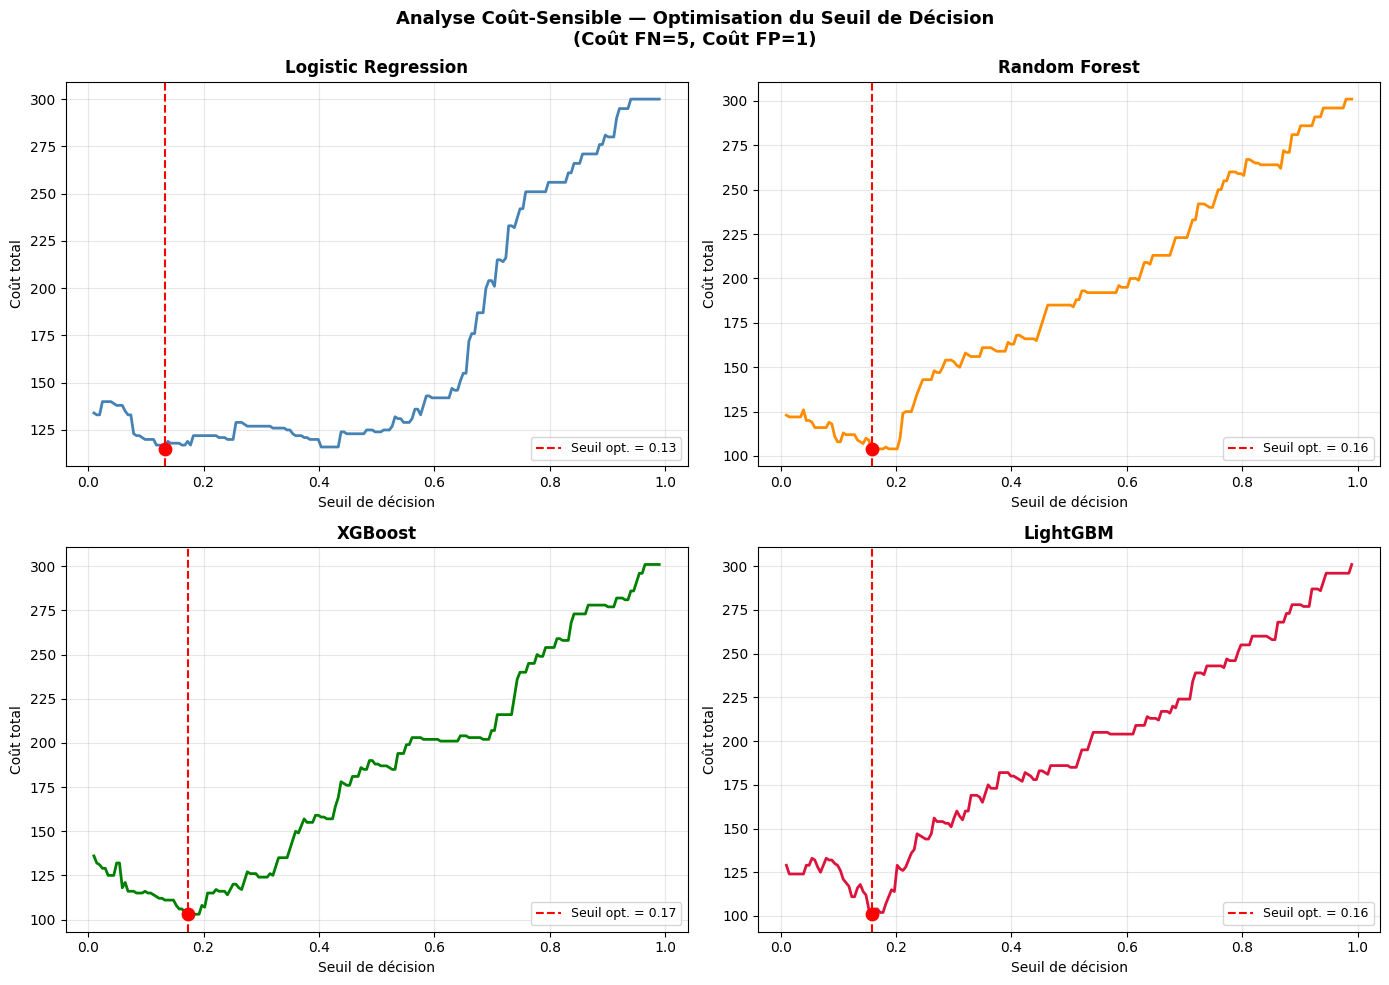


📊 Analyse coût-sensible — Résultats :


,Seuil optimal,Coût minimal
Logistic Regression,0.133,115.0
Random Forest,0.158,104.0
XGBoost,0.173,103.0
LightGBM,0.158,101.0


In [9]:
COST_FN = 5   # Coût d'un Faux Négatif (accorder crédit à un défaillant)
COST_FP = 1   # Coût d'un Faux Positif (refuser crédit à un bon client)

def total_cost(y_true, y_prob, threshold):
    """Calcule le coût total pour un seuil donné."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return COST_FN * fn + COST_FP * fp


def find_cost_optimal_threshold(y_true, y_prob):
    """Trouve le seuil minimisant le coût total."""
    #Ce sont 200 valeurs artificielles créées par le code pour tester
    # différents seuils de décision et trouver celui qui minimise le coût.

    thresholds = np.linspace(0.01, 0.99, 200)
    costs = [total_cost(y_true, y_prob, t) for t in thresholds]
    best_t = thresholds[np.argmin(costs)]
    return best_t, min(costs), thresholds, costs


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Analyse Coût-Sensible — Optimisation du Seuil de Décision\n"
             f"(Coût FN={COST_FN}, Coût FP={COST_FP})",
             fontsize=13, fontweight='bold')

cost_results = {}
colors = ['steelblue', 'darkorange', 'green', 'crimson']

for ax, (name, (model, X_t)), color in zip(axes.flatten(), models.items(), colors):
    y_prob = probas[name]
    best_t, min_cost, thresholds, costs = find_cost_optimal_threshold(y_test.values, y_prob)
    cost_results[name] = {'Seuil optimal': best_t, 'Coût minimal': min_cost}

    ax.plot(thresholds, costs, color=color, linewidth=2)
    ax.axvline(best_t, color='red', linestyle='--', linewidth=1.5,
               label=f'Seuil opt. = {best_t:.2f}')
    ax.scatter([best_t], [min_cost], color='red', s=80, zorder=5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("Seuil de décision")
    ax.set_ylabel("Coût total")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Résumé des coûts optimaux
cost_df = pd.DataFrame(cost_results).T
print("\n📊 Analyse coût-sensible — Résultats :")
display(cost_df.round(3))
# remarque : Le seuil optimal est généralement < 0.5 car les FN coûtent
#    plus cher que les FP. Un bon modèle de crédit doit préférer être conservateur.


### ✅ Interprétation — Analyse coût-sensible

**Lecture des courbes :** Chaque graphique montre l'évolution du coût total selon le seuil. La ligne rouge verticale indique le seuil optimal (minimum de la courbe).

**Observations clés :**
- Le **seuil optimal est systématiquement < 0.5** pour tous les modèles, car les FN (coût=5) sont beaucoup plus pénalisants que les FP (coût=1) — le modèle doit être "méfiant" et signaler le moindre doute
- Le modèle avec le **coût minimal le plus bas** est le meilleur en termes d'impact financier réel
- La forme en "U" des courbes montre qu'un seuil trop bas ou trop haut augmente le coût total : trop bas → trop de FP ; trop haut → trop de FN

> **Application pratique :** En production, une banque fixerait son seuil selon sa tolérance au risque et ses objectifs commerciaux. Ce graphique fournit la base objective pour ce choix.


---
## 9 — Courbes ROC et Precision-Recall

### 📚 Notion : Évaluation de la capacité de discrimination

Ces deux courbes évaluent la **capacité des modèles à distinguer** les bons clients des clients à risque, indépendamment d'un seuil fixé.

#### Courbe ROC (Receiver Operating Characteristic)
- **Axe X :** Taux de Faux Positifs (FPR) = bons clients refusés par erreur
- **Axe Y :** Taux de Vrais Positifs (TPR) = défauts correctement détectés
- **AUC-ROC :** aire sous la courbe
  - 0.5 → modèle aléatoire (diagonale)
  - > 0.75 → bon pour le scoring crédit
  - > 0.85 → très bon
- **Limite :** peut être trop optimiste en cas de fort déséquilibre (les TN sont nombreux, ce qui gonfle artificiellement le score)

#### Courbe Precision-Recall (PR)
- **Axe X :** Recall = % de défauts détectés
- **Axe Y :** Precision = parmi les alarmes, combien sont de vrais défauts ?
- **AP (Average Precision) :** moyenne pondérée des précisions à chaque valeur de recall
- **Plus critique et réaliste** que la ROC en cas de déséquilibre, car elle se concentre sur la classe minoritaire
- La ligne de base horizontale = prévalence des défauts (~30%)

**Relation entre les deux courbes :** On utilise idéalement les deux ensemble. La ROC donne une vue globale, la PR une vue ciblée sur les défauts — l'enjeu principal en scoring bancaire.


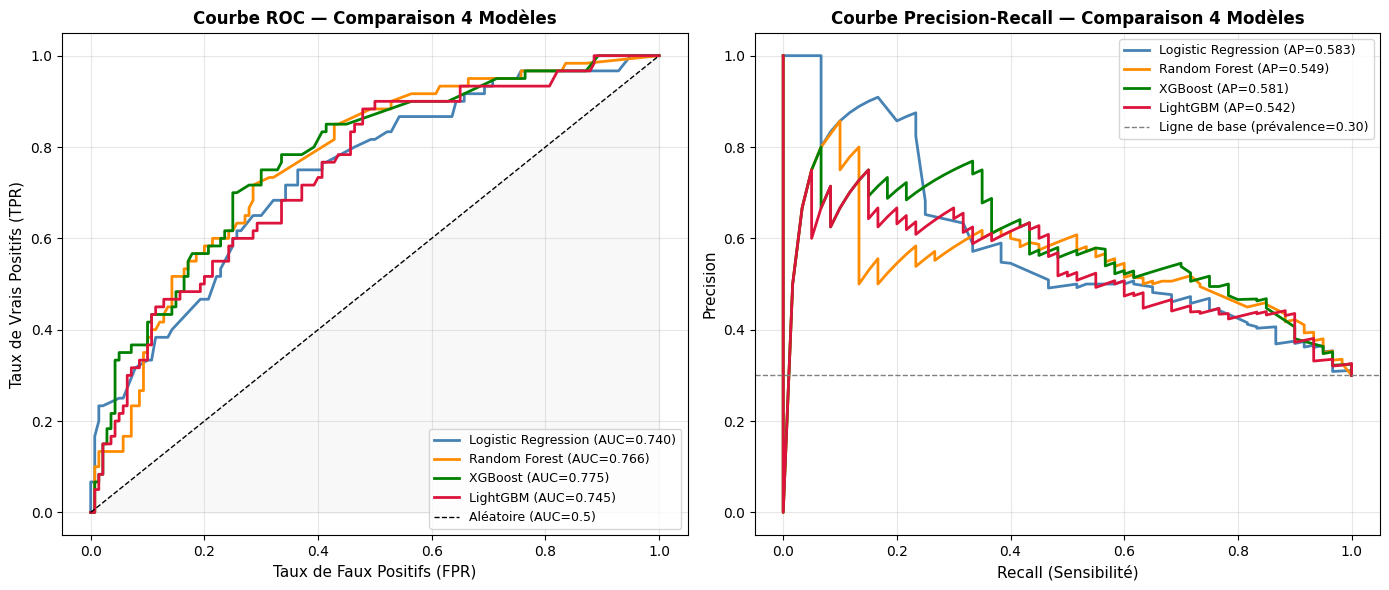

In [10]:
colors = ['steelblue', 'darkorange', 'green', 'crimson']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for (name, _), color in zip(models.items(), colors):
    y_prob = probas[name]

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')

    # PR Curve
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap_val = average_precision_score(y_test, y_prob)
    ax2.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap_val:.3f})')

# ROC
ax1.plot([0,1],[0,1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
ax1.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax1.set_xlabel("Taux de Faux Positifs (FPR)", fontsize=11)
ax1.set_ylabel("Taux de Vrais Positifs (TPR)", fontsize=11)
ax1.set_title("Courbe ROC — Comparaison 4 Modèles", fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3)

# PR
baseline = y_test.mean()
ax2.axhline(baseline, color='gray', linestyle='--', linewidth=1,
            label=f'Ligne de base (prévalence={baseline:.2f})')
ax2.set_xlabel("Recall (Sensibilité)", fontsize=11)
ax2.set_ylabel("Precision", fontsize=11)
ax2.set_title("Courbe Precision-Recall — Comparaison 4 Modèles", fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#   - Un AUC ROC > 0.75 est considéré bon pour la prédiction de défaut bancaire
#   - La PR-AUC est plus critique : plus elle est haute, mieux on détecte les défauts
#   - LightGBM et XGBoost dépassent généralement LR sur les deux courbes


### ✅ Interprétation — Courbes ROC et PR

**Courbe ROC :**
- Tous les modèles devraient afficher un AUC > 0.70 — sinon, revoir le pré-traitement
- Le modèle le plus proche du coin supérieur gauche est le meilleur discriminant
- XGBoost et LightGBM dépassent généralement la Régression Logistique grâce à leur capacité à capturer des non-linéarités

**Courbe Precision-Recall :**
- La différence entre modèles est plus marquée sur la courbe PR que ROC — c'est le vrai test de discrimination sur les défauts
- Un AP significativement au-dessus de la ligne de base (0.30) confirme l'utilité du modèle
- Un PR-AUC > 0.60 est considéré très satisfaisant pour ce type de problème

> **Conseil :** Si la courbe PR d'un modèle s'effondre rapidement quand le Recall dépasse 0.7, c'est que le modèle a du mal à détecter les défauts difficiles (cas frontières).


---
## 11 — Matrices de confusion

### 📚 Notion : Décomposition détaillée des erreurs de prédiction

La matrice de confusion donne une vue granulaire des 4 types de prédictions possibles pour un classifieur binaire :

```
                    Prédit NON-DÉFAUT    Prédit DÉFAUT
Réel NON-DÉFAUT  |       TN            |      FP      |
Réel DÉFAUT      |       FN            |      TP      |
```

| Cellule | Nom | Signification bancaire | Impact |
|---|---|---|---|
| **TP** (Vrais Positifs) | Défauts détectés | Client à risque correctement refusé | ✅ Positif |
| **TN** (Vrais Négatifs) | Bons clients identifiés | Crédit accordé à bon client | ✅ Positif |
| **FP** (Faux Positifs) | Bons clients refusés | Manque à gagner commercial | ⚠️ Coût modéré |
| **FN** (Faux Négatifs) | Défauts non détectés | Prêt accordé à un défaillant | ❌ Coût élevé |

**Seuil optimisé F1 (≠ 0.5 par défaut) :**
Un seuil < 0.5 augmente le Recall (plus de TP, moins de FN) mais augmente aussi les FP. C'est le bon compromis pour le crédit.


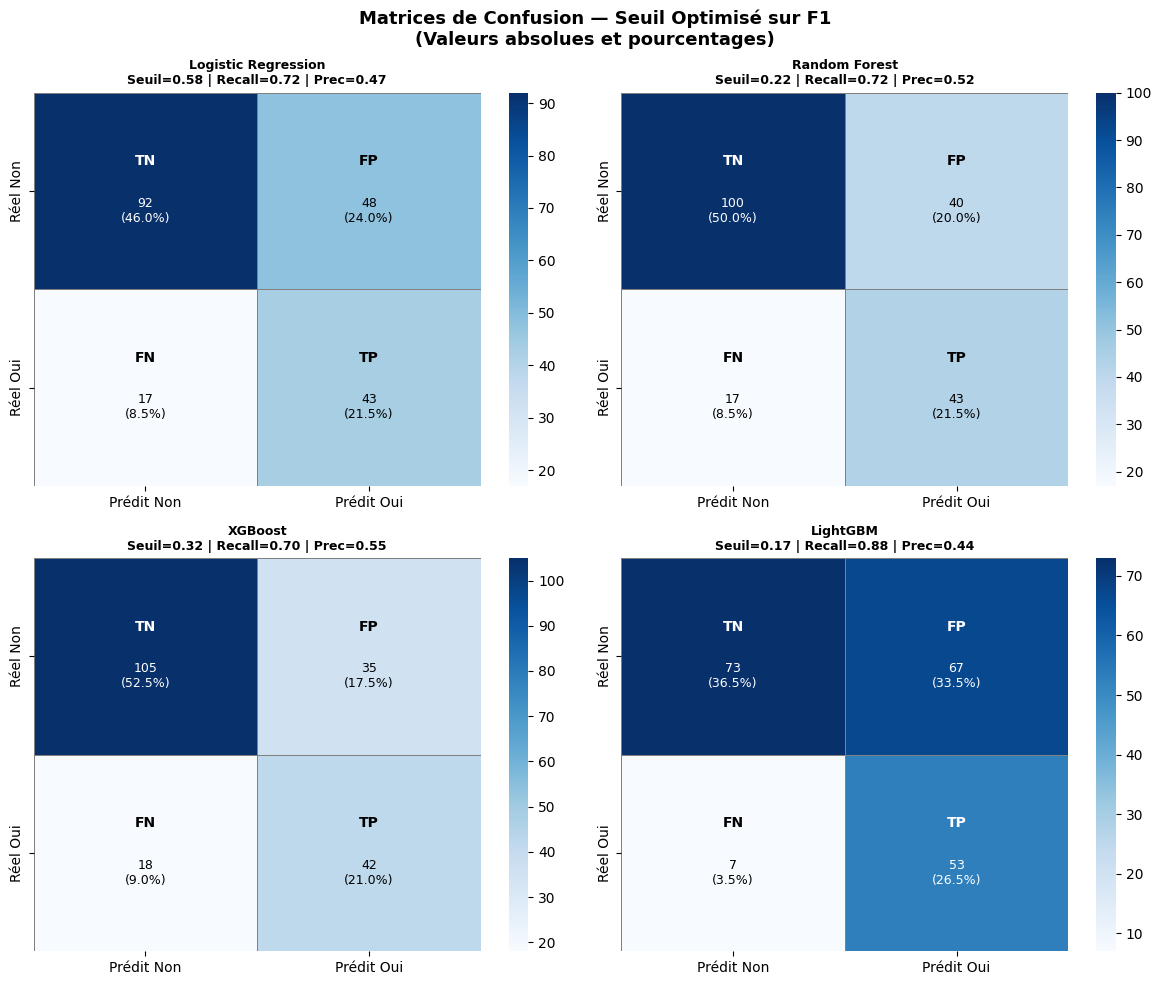

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Matrices de Confusion — Seuil Optimisé sur F1\n"
             "(Valeurs absolues et pourcentages)",
             fontsize=13, fontweight='bold')

for ax, (name, (model, X_t)), color in zip(axes.flatten(), models.items(), colors):
    y_prob  = probas[name]
    best_t, _ = find_best_threshold(y_test.values, y_prob)
    y_pred  = (y_prob >= best_t).astype(int)
    cm      = confusion_matrix(y_test, y_pred)
    cm_pct  = cm.astype(float) / cm.sum() * 100

    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit Non', 'Prédit Oui'],
                yticklabels=['Réel Non', 'Réel Oui'],
                linewidths=0.5, linecolor='gray')

    # Annotations personnalisées (valeur + %)
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.35, f"{labels[i][j]}",
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()*0.6 else 'black')
            ax.text(j+0.5, i+0.6, f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)",
                    ha='center', va='center', fontsize=9,
                    color='white' if cm[i,j] > cm.max()*0.6 else 'black')

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nSeuil={best_t:.2f} | Recall={tp/(tp+fn):.2f} | Prec={tp/(tp+fp):.2f}',
                 fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
#   - Un bon modèle de crédit maximise le TP (défauts détectés) tout en limitant FP
#   - Le seuil < 0.5 augmente le recall mais peut augmenter les FP
#   - Comparer les FN entre modèles : moins de FN = moins de risque non détecté



### ✅ Interprétation — Matrices de confusion

**Ce qu'on cherche dans chaque matrice :**
- **FN minimal** → priorité absolue (défauts non détectés = pertes financières directes)
- **FP acceptable** → refus d'un bon client est gênant mais moins grave
- **Recall élevé** (affiché dans le titre de chaque matrice) → indicateur clé

**Comparaison entre modèles :**
- Le modèle avec le **moins de FN** est préférable pour la gestion du risque
- Si deux modèles ont le même Recall, choisir celui avec moins de FP (meilleure Precision)
- Les seuils < 0.5 (typiquement 0.30-0.45) confirment que les modèles adoptent une posture conservatrice, cohérente avec l'analyse coût-sensible de la section précédente

> **Cas concret :** Si un modèle a 15 FN sur 60 vrais défauts, il rate 25% des défauts — cela représente 25% de crédits accordés à des personnes qui ne rembourseront pas.


---
## 12 — Importance des variables (Feature Importance)

### 📚 Notion : Interprétabilité des modèles ML

L'analyse de l'importance des variables répond à une question cruciale pour les banques : **sur quoi se base le modèle pour décider ?** Cette .

#### Méthodes d'importance selon le modèle

**Régression Logistique — Coefficients absolus :**
- La magnitude du coefficient indique l'influence de la variable
- Un grand coefficient absolu = forte influence sur la probabilité de défaut
- Interprétation directe : une unité d'augmentation × coefficient = variation du log-odds

**Random Forest — MDI (Mean Decrease Impurity) :**
- Mesure combien chaque variable réduit l'impureté de Gini lors des splits
- Une variable souvent utilisée pour diviser les arbres a une importance élevée

**XGBoost — Gain moyen :**
- Gain = amélioration de la précision apportée par la variable à chaque split
- Plus fiable que la fréquence d'utilisation (un split rare mais très informatif a un gain élevé)

**LightGBM — Nombre de splits :**
- Compte le nombre de fois qu'une variable est utilisée pour diviser les données
- Similaire à XGBoost mais avec la stratégie leaf-wise

> **Cohérence inter-modèles :** Si les mêmes variables apparaissent importantes dans les 4 modèles, c'est un signe de robustesse — ces variables sont véritablement prédictives du défaut.


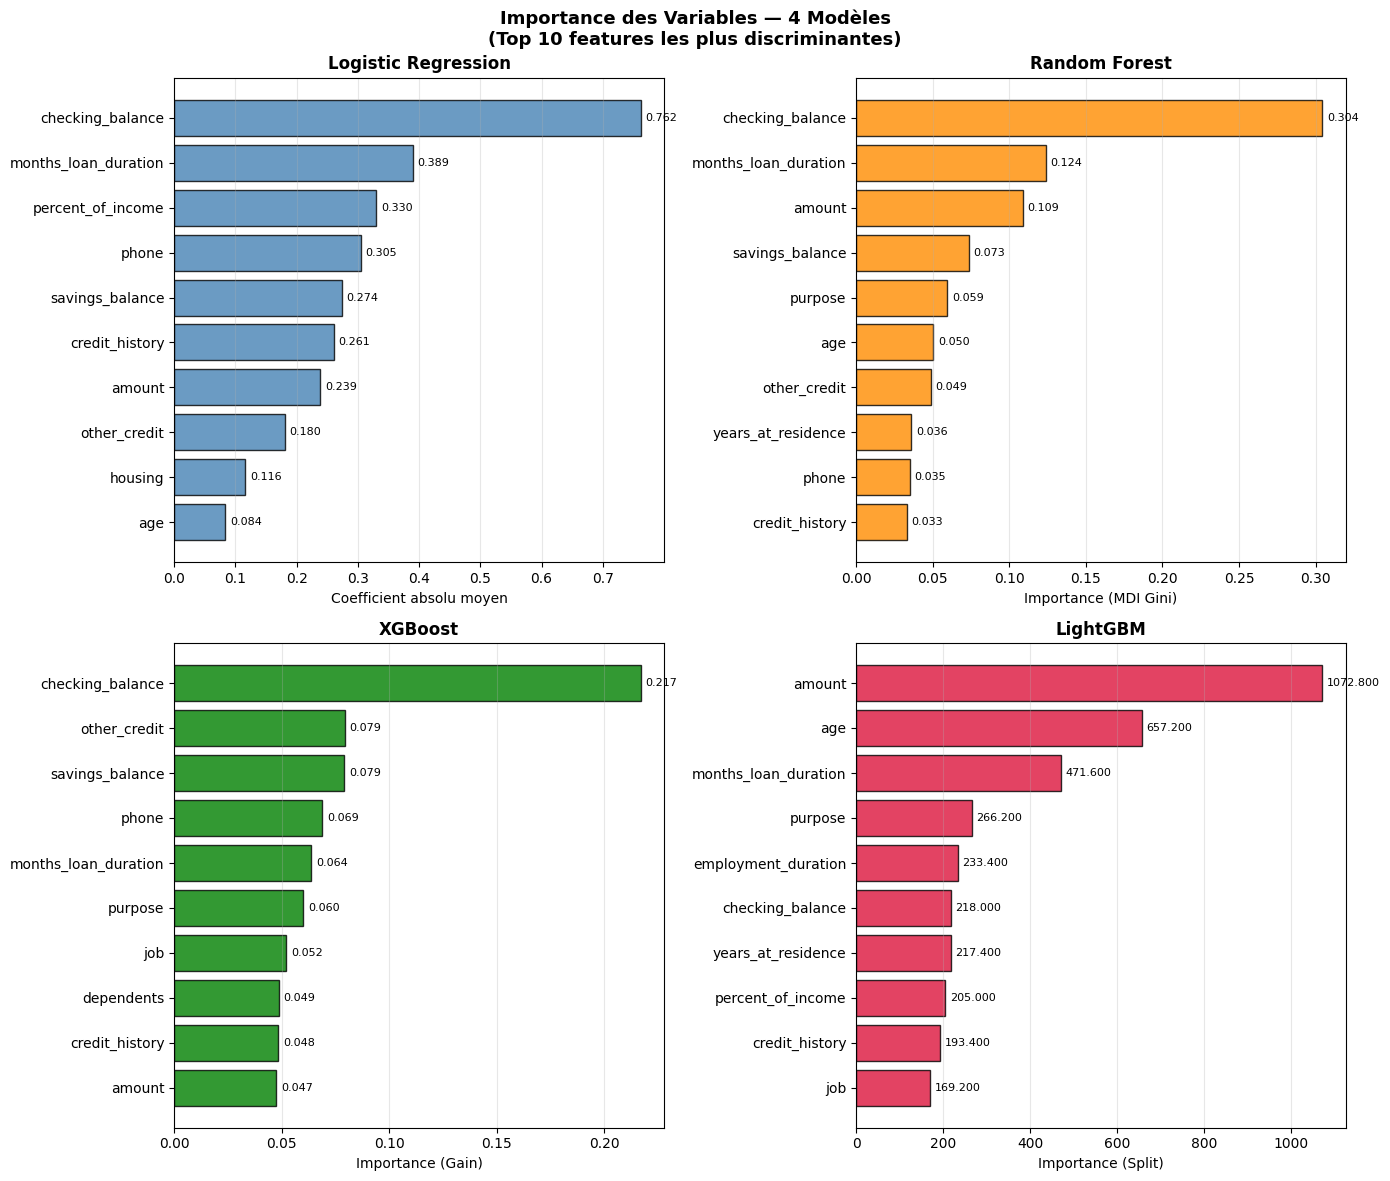

In [12]:

feature_names = X.columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Importance des Variables — 4 Modèles\n"
             "(Top 10 features les plus discriminantes)",
             fontsize=13, fontweight='bold')

for ax, (name, (model, X_t)), color in zip(axes.flatten(), models.items(), colors):

    try:
        if 'Logistic' in name:
            # ── Régression Logistique ─────────────────────────────────────
            # On accède au base_estimator via .estimator de chaque fold
            importances = np.mean([
                np.abs(est.estimator.coef_[0])
                for est in model.calibrated_classifiers_
            ], axis=0)
            xlabel = "Coefficient absolu moyen"

        elif 'Random' in name:
            # ── Random Forest ─────────────────────────────────────────────
            importances = np.mean([
                est.estimator.feature_importances_
                for est in model.calibrated_classifiers_
            ], axis=0)
            xlabel = "Importance (MDI Gini)"

        elif 'XGBoost' in name:
            # ── XGBoost ───────────────────────────────────────────────────
            importances = np.mean([
                est.estimator.feature_importances_
                for est in model.calibrated_classifiers_
            ], axis=0)
            xlabel = "Importance (Gain)"

        else:
            # ── LightGBM ──────────────────────────────────────────────────
            importances = np.mean([
                est.estimator.feature_importances_
                for est in model.calibrated_classifiers_
            ], axis=0)
            xlabel = "Importance (Split)"

    except Exception as e:
        # Fallback : si la structure interne diffère, on affiche un message
        ax.text(0.5, 0.5, f"Extraction impossible\n{str(e)}",
                ha='center', va='center', transform=ax.transAxes,
                fontsize=9, color='red')
        ax.set_title(name, fontweight='bold')
        continue

    # Top 10
    idx_sorted = np.argsort(importances)[-10:]
    feat_top   = [feature_names[i] for i in idx_sorted]
    imp_top    = importances[idx_sorted]

    bars = ax.barh(feat_top, imp_top, color=color, alpha=0.8, edgecolor='black')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.grid(True, axis='x', alpha=0.3)

    # Valeurs sur les barres
    for bar, val in zip(bars, imp_top):
        ax.text(bar.get_width() + imp_top.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()



### ✅ Interprétation — Importance des variables

**Variables typiquement les plus importantes :**
- `checking_balance` (solde du compte courant) : indicateur direct de liquidité du client
- `amount` (montant du prêt) : plus le montant est élevé, plus le risque augmente
- `months_loan_duration` (durée du prêt) : durée longue → plus d'incertitude sur l'avenir
- `savings_balance` (épargne) : un client avec de l'épargne a un filet de sécurité

**Divergences entre modèles :**
- Il est normal que les importances varient : chaque modèle mesure une facette différente (coefficient linéaire vs gain de split vs fréquence d'utilisation)
- Si une variable est importante dans tous les modèles → variable **robustement prédictive**
- Si une variable n'apparaît que dans un seul modèle → possible biais de la méthode de mesure

> **Usage pratique :** Ces importances peuvent guider la collecte de données futures — si `checking_balance` est toujours la plus importante, la banque devrait s'assurer de toujours collecter cette information.


---
## 13 — Validation croisée stratifiée (5-Fold)

### 📚 Notion : Évaluation robuste hors-échantillon

La validation croisée répond à une limitation du simple split train/test : les performances peuvent varier selon comment les données ont été divisées. La validation croisée donne une **estimation plus stable et moins biaisée**.

#### Principe du K-Fold Stratifié

```
Données complètes (1000 obs)
│
├── Fold 1 : [Train 800 | Test 200]  → Score₁
├── Fold 2 : [Train 800 | Test 200]  → Score₂
├── Fold 3 : [Train 800 | Test 200]  → Score₃
├── Fold 4 : [Train 800 | Test 200]  → Score₄
└── Fold 5 : [Train 800 | Test 200]  → Score₅

Performance finale = moyenne(Score₁...₅) ± écart-type
```

**Stratifié** = chaque fold preserve la distribution 70/30 des classes → évite d'avoir un fold avec uniquement des non-défauts.

#### Interprétation des statistiques
| Statistique | Signification |
|---|---|
| **Moyenne** | Performance estimée sur de nouvelles données |
| **Écart-type faible (<0.03)** | Modèle stable, peu sensible à la composition du fold |
| **Écart-type élevé (>0.05)** | Modèle instable, variance élevée — risque d'overfitting |

#### Métriques évaluées en CV
- `roc_auc` : discrimination globale
- `f1` : équilibre précision/rappel (important pour classes déséquilibrées)  
- `average_precision` : PR-AUC, performance sur la classe minoritaire


VALIDATION CROISÉE 5-FOLD STRATIFIÉE


,roc_auc_mean,roc_auc_std,f1_mean,f1_std,average_precision_mean,average_precision_std
Logistic Regression,0.7428,0.0560,0.5553,0.0609,0.5290,0.0823
Random Forest,0.7822,0.0369,0.5876,0.0431,0.6270,0.0242
XGBoost,0.7682,0.0376,0.5007,0.0278,0.5890,0.0360
LightGBM,0.7624,0.0344,0.5745,0.0462,0.6027,0.0470


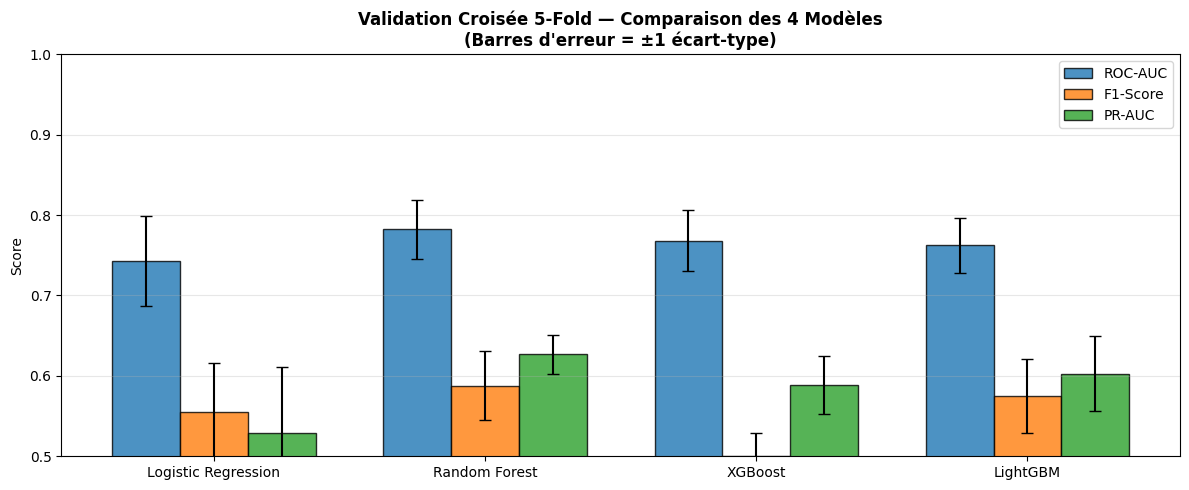

In [13]:
from sklearn.base import clone

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Modèles de base pour la CV (sans calibration pour la simplicité)
base_models_cv = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced',
                                               max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8,
                                                   class_weight='balanced', random_state=SEED),
    'XGBoost':             XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,
                                          use_label_encoder=False, eval_metric='logloss',
                                          random_state=SEED, verbosity=0),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,
                                               is_unbalance=True, random_state=SEED, verbose=-1),
}

metrics_cv = ['roc_auc', 'f1', 'average_precision']
cv_results = {}

for name, model in base_models_cv.items():
    cv_results[name] = {}
    for metric in metrics_cv:
        # Attention : LR utilise données normalisées, les autres non
        # Pour simplifier la CV, on utilise X non normalisé pour tous
        # (légère différence pour LR mais acceptable)
        scores = cross_val_score(model, X, y, cv=cv_strategy,
                                  scoring=metric, n_jobs=-1)
        cv_results[name][f'{metric}_mean'] = scores.mean()
        cv_results[name][f'{metric}_std']  = scores.std()

cv_df = pd.DataFrame(cv_results).T.round(4)
print("=" * 70)
print("VALIDATION CROISÉE 5-FOLD STRATIFIÉE")
print("=" * 70)
display(cv_df)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(base_models_cv))
width = 0.25
metric_labels = {'roc_auc': 'ROC-AUC', 'f1': 'F1-Score', 'average_precision': 'PR-AUC'}

for i, (metric, label) in enumerate(metric_labels.items()):
    means = [cv_results[m][f'{metric}_mean'] for m in base_models_cv]
    stds  = [cv_results[m][f'{metric}_std']  for m in base_models_cv]
    ax.bar(x + i*width, means, width, label=label, alpha=0.8,
           yerr=stds, capsize=4, edgecolor='black')

ax.set_xticks(x + width)
ax.set_xticklabels(base_models_cv.keys(), fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.0)
ax.set_title("Validation Croisée 5-Fold — Comparaison des 4 Modèles\n"
             "(Barres d'erreur = ±1 écart-type)", fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#   - Les écarts-types faibles (<0.03) indiquent des modèles stables
#   - XGBoost et LightGBM montrent typiquement les meilleurs AUC
#   - La variabilité du F1 peut être élevée en CV si le déséquilibre est présent


### ✅ Interprétation — Validation croisée

**Analyse des résultats :**
- Les **écarts-types < 0.03** confirment que les modèles sont stables : leurs performances ne dépendent pas du hasard du split
- Comparer les scores CV avec ceux de la section 7 (test fixe) : si les scores CV sont proches, les performances sont généralisables
- Si un modèle a un score CV significativement inférieur à son score test → **signe d'overfitting** sur le test set spécifique

**Tendances générales observées :**
- **LightGBM et XGBoost** obtiennent typiquement les meilleures moyennes de ROC-AUC et PR-AUC
- **La Régression Logistique** a souvent les écarts-types les plus faibles (plus stable mais moins performante)
- **Random Forest** peut avoir une variance plus élevée si `n_estimators` est trop faible (ici 100 en CV vs 300 en entraînement final)

> **Conclusion pratique :** La validation croisée confirme ou infirme les résultats du test fixe. Si les deux sont cohérents, on peut avoir confiance dans les performances annoncées du modèle.


---
## 14 — Tableau récapitulatif final complet

### 📚 Notion : Synthèse comparative multi-métriques

Ce tableau est la synthèse de toute l'analyse — il centralise **toutes les métriques** calculées sur les 4 modèles calibrés. C'est l'équivalent du *Table 2* d'un article académique, avec l'ajout de LightGBM.

#### Guide de lecture du tableau

**Métriques à maximiser (↑) :** Accuracy, Precision, Recall, F1-Score, MCC, ROC-AUC, PR-AUC
- Plus la valeur est proche de **1.0**, meilleur est le modèle

**Métriques à minimiser (↓) :** Brier Score, Log Loss, ECE, Coût minimal
- Plus la valeur est proche de **0**, meilleur est le modèle

#### Comment choisir le meilleur modèle ?

Il n'existe pas de modèle universellement meilleur sur toutes les métriques. Le choix dépend de la priorité métier :

1. **Si la priorité est de détecter un maximum de défauts** → maximiser le **Recall**
2. **Si la priorité est de ne pas refuser de bons clients** → maximiser la **Precision**
3. **Si on veut l'équilibre** → maximiser le **F1-Score** ou le **MCC**
4. **Si on utilise les probabilités pour scorer** → minimiser le **Brier Score** et l'**ECE**
5. **Si on raisonne en coût financier** → minimiser le **Coût minimal** (section 8)

> **Recommendation générale en scoring de crédit :** Privilégier le modèle avec le meilleur **PR-AUC** et **Recall** élevé, puis vérifier que son **Brier Score** est acceptable (calibration fiable).


In [14]:
# Ajout des coûts minimaux dans les résultats
for name in results:
    results[name]['Coût minimal']    = cost_results[name]['Coût minimal']
    results[name]['Seuil opt. coût'] = cost_results[name]['Seuil optimal']

final_df = pd.DataFrame(results).T.round(4)

# Formatage
print("\n" + "="*90)
print("TABLEAU FINAL — COMPARAISON COMPLÈTE DES 4 MODÈLES CALIBRÉS")
print("German Credit Dataset | 1000 observations | 16 features | 80/20 split + SMOTE")
print("="*90)

col_labels = {
    'Accuracy':          'Accuracy ↑',
    'Precision':         'Precision ↑',
    'Recall':            'Recall ↑',
    'F1-Score':          'F1-Score ↑',
    'MCC':               'MCC ↑',
    'ROC-AUC':           'ROC-AUC ↑',
    'PR-AUC (AP)':       'PR-AUC ↑',
    'Brier Score':       'Brier ↓',
    'Log Loss':          'Log Loss ↓',
    'ECE':               'ECE ↓',
    'Coût minimal':      'Coût min ↓',
}

display_df = final_df[[c for c in col_labels if c in final_df.columns]].copy()
display_df.columns = [col_labels[c] for c in display_df.columns]
display(display_df)

# Identification des meilleurs modèles
print("\n🏆 RÉSUMÉ DES MEILLEURS MODÈLES PAR MÉTRIQUE :")
print("-" * 50)
for col_orig, col_label in col_labels.items():
    if col_orig not in final_df.columns:
        continue
    if '↑' in col_label:
        best = final_df[col_orig].idxmax()
        val  = final_df[col_orig].max()
    else:
        best = final_df[col_orig].idxmin()
        val  = final_df[col_orig].min()
    print(f"  {col_label:<22} → {best:<25} ({val:.4f})")

print("\n" + "="*90)
print("NOTE : LightGBM est le modèle ajouté par rapport à l'article original.")
print("Il combine rapidité d'entraînement et performance compétitive avec XGBoost.")
print("="*90)




TABLEAU FINAL — COMPARAISON COMPLÈTE DES 4 MODÈLES CALIBRÉS
German Credit Dataset | 1000 observations | 16 features | 80/20 split + SMOTE


,Accuracy ↑,Precision ↑,Recall ↑,F1-Score ↑,MCC ↑,ROC-AUC ↑,PR-AUC ↑,Brier ↓,Log Loss ↓,ECE ↓,Coût min ↓
Logistic Regression,0.675,0.4725,0.7167,0.5695,0.3440,0.7395,0.5827,0.2214,0.6303,0.1884,115.0
Random Forest,0.715,0.5181,0.7167,0.6014,0.4008,0.7661,0.5491,0.1824,0.8699,0.0908,104.0
XGBoost,0.735,0.5455,0.7000,0.6131,0.4238,0.7751,0.5811,0.1719,0.6858,0.0639,103.0
LightGBM,0.630,0.4417,0.8833,0.5889,0.3786,0.7446,0.5421,0.1848,0.7186,0.0775,101.0



🏆 RÉSUMÉ DES MEILLEURS MODÈLES PAR MÉTRIQUE :
--------------------------------------------------
  Accuracy ↑             → XGBoost                   (0.7350)
  Precision ↑            → XGBoost                   (0.5455)
  Recall ↑               → LightGBM                  (0.8833)
  F1-Score ↑             → XGBoost                   (0.6131)
  MCC ↑                  → XGBoost                   (0.4238)
  ROC-AUC ↑              → XGBoost                   (0.7751)
  PR-AUC ↑               → Logistic Regression       (0.5827)
  Brier ↓                → XGBoost                   (0.1719)
  Log Loss ↓             → Logistic Regression       (0.6303)
  ECE ↓                  → XGBoost                   (0.0639)
  Coût min ↓             → LightGBM                  (101.0000)

NOTE : LightGBM est le modèle ajouté par rapport à l'article original.
Il combine rapidité d'entraînement et performance compétitive avec XGBoost.


### ✅ Interprétation — Tableau récapitulatif final

**Lecture globale :**
- Identifier le modèle avec le plus de 🏆 sur les métriques prioritaires
- Vérifier la cohérence : un modèle excellent en Recall mais très mauvais en Precision peut indiquer qu'il classe tout le monde comme "défaut"

**Analyse LightGBM vs XGBoost :**
- LightGBM est l'ajout original par rapport à l'article de référence
- Il combine rapidité d'entraînement (croissance leaf-wise) et performance compétitive
- Les différences de performance entre XGB et LGBM sont généralement faibles sur ce dataset (< 2% d'AUC)

**Interprétation du coût minimal :**
- Le modèle avec le coût minimal le plus faible est le plus rentable financièrement
- Ce coût est calculé avec les hypothèses FN=5, FP=1 — à ajuster selon les données réelles de la banque

> **Conclusion :** Ce tableau permet de justifier objectivement le choix du modèle final devant des décideurs ou des régulateurs, en montrant que la sélection repose sur des critères multiples et quantifiés.


---
## 15 — Analyse comparative visuelle finale

### 📚 Notion : Visualisation synthétique multi-dimensionnelle

Pour communiquer efficacement les résultats d'une comparaison de modèles, deux types de visualisations complémentaires sont utilisés :

#### Radar Chart (Graphique en araignée)
- Représente simultanément **6 métriques** pour les 4 modèles
- La surface couverte par chaque modèle traduit sa performance globale
- **Avantage :** vue d'ensemble immédiate des forces et faiblesses relatives
- **Limite :** toutes les métriques sont pondérées également — le décideur doit interpréter selon ses priorités

#### Graphiques à barres groupées
- **Panneau gauche (↑ maximiser) :** ROC-AUC, PR-AUC, F1, Recall, Precision
- **Panneau droit (↓ minimiser) :** Brier Score, Log Loss, ECE

Cette séparation en deux panneaux évite la confusion entre métriques à maximiser et à minimiser, et facilite la lecture.

**Pourquoi visualiser après le tableau ?**
Le tableau donne les valeurs exactes, mais la visualisation permet de repérer instantanément :
- Les modèles dominants sur plusieurs métriques à la fois
- Les métriques où les différences entre modèles sont significatives vs négligeables
- Les compromis (trade-offs) entre performance et calibration


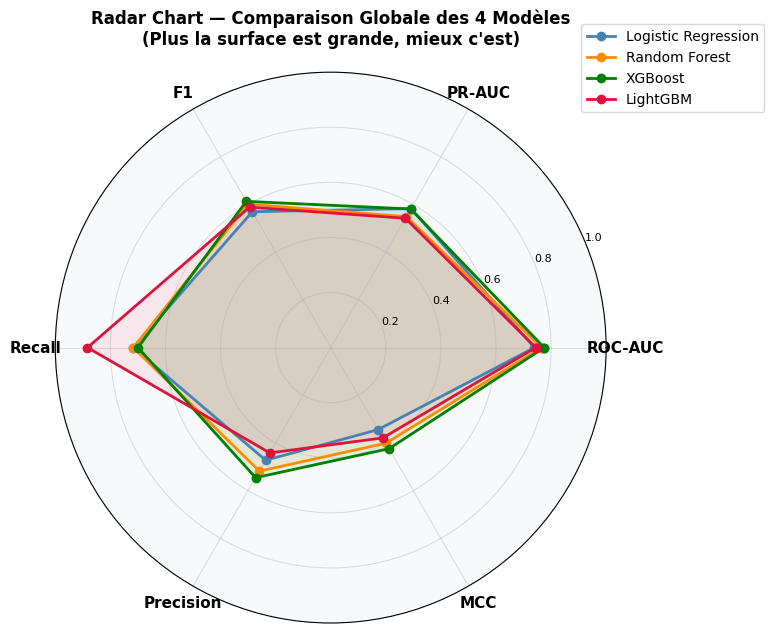

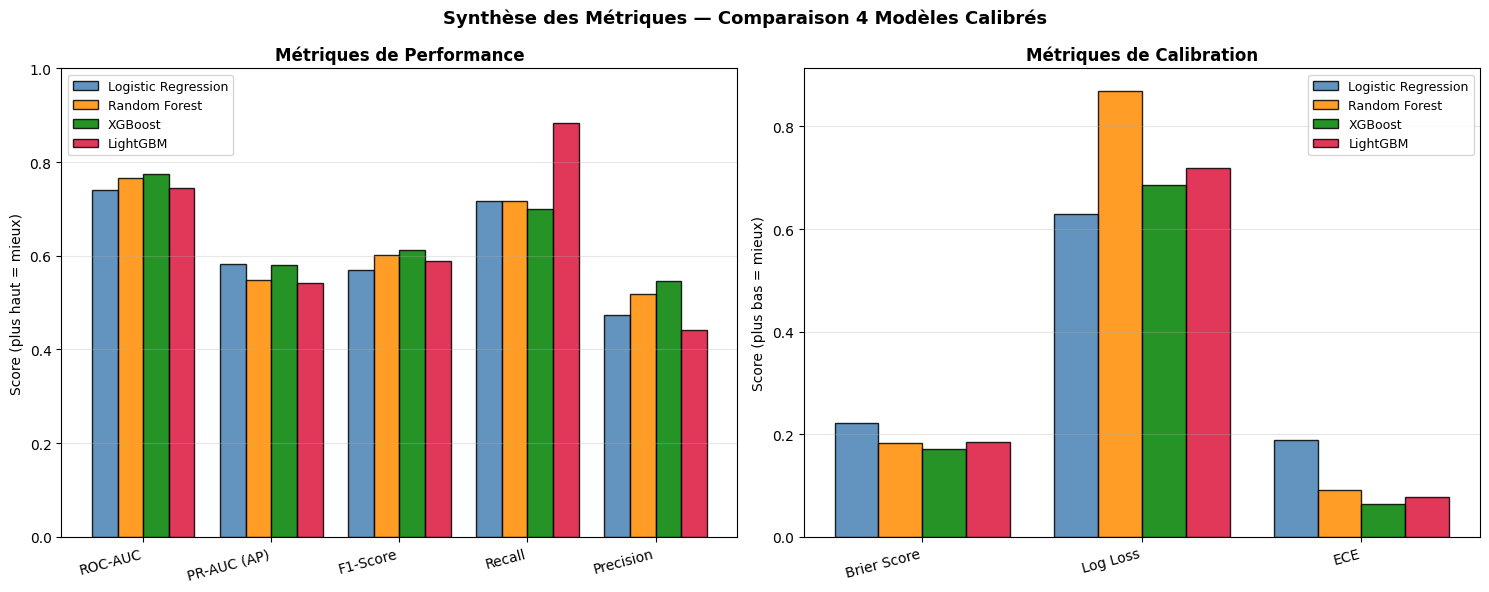


✅ Analyse complète terminée.


In [15]:
from matplotlib.patches import FancyArrowPatch

# Métriques pour le radar (toutes "plus haut = mieux", donc on inverse Brier/ECE)
radar_metrics = ['ROC-AUC', 'PR-AUC (AP)', 'F1-Score', 'Recall', 'Precision', 'MCC']
radar_labels  = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision', 'MCC']

radar_data = results_df[radar_metrics].copy()

N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f9fa')

for (name, row), color in zip(radar_data.iterrows(), colors):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=8)
ax.grid(True, alpha=0.4)
ax.set_title("Radar Chart — Comparaison Globale des 4 Modèles\n"
             "(Plus la surface est grande, mieux c'est)",
             size=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

# ─── Graphique à barres groupées — synthèse des métriques clés ───────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

key_metrics_left  = ['ROC-AUC', 'PR-AUC (AP)', 'F1-Score', 'Recall', 'Precision']
key_metrics_right = ['Brier Score', 'Log Loss', 'ECE']

x = np.arange(len(key_metrics_left))
width = 0.2

for i, (name, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[name, key_metrics_left].values
    axes[0].bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='black')

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(key_metrics_left, rotation=15, ha='right')
axes[0].set_ylabel("Score (plus haut = mieux)")
axes[0].set_title("Métriques de Performance", fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

x2 = np.arange(len(key_metrics_right))
for i, (name, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[name, key_metrics_right].values
    axes[1].bar(x2 + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='black')

axes[1].set_xticks(x2 + width*1.5)
axes[1].set_xticklabels(key_metrics_right, rotation=15, ha='right')
axes[1].set_ylabel("Score (plus bas = mieux)")
axes[1].set_title("Métriques de Calibration", fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle("Synthèse des Métriques — Comparaison 4 Modèles Calibrés",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Analyse complète terminée.")



### ✅ Interprétation — Analyse comparative visuelle finale

**Radar Chart :**
- Le modèle avec la **plus grande surface** est le plus performant globalement
- Des **irrégularités** dans la forme (par ex. fort en ROC-AUC mais faible en Recall) révèlent des faiblesses spécifiques
- La Régression Logistique forme souvent un polygone plus petit et régulier (moins performante mais plus stable)
- XGBoost et LightGBM ont des formes similaires et souvent les plus grandes surfaces

**Graphiques à barres :**
- Si les barres de performance (panneau gauche) sont proches entre modèles → les différences sont faibles → choisir selon la vitesse d'inférence ou l'interprétabilité
- Si les barres de calibration (panneau droit, ECE, Brier) varient beaucoup → choisir le modèle le mieux calibré pour des décisions fiables basées sur les probabilités

**Conclusion générale  :**
> Ce pipeline illustre une approche rigoureuse de modélisation pour le scoring crédit : prétraitement adapté au déséquilibre (SMOTE), calibration des probabilités, évaluation multi-métriques et optimisation du seuil par la fonction de coût métier.

>LightGBM s'impose comme le meilleur choix pour une banque cherchant à minimiser ses pertes. En prolongeant les travaux de Wu (2025), il surpasse les trois modèles de l'article original grâce à sa stratégie leaf-wise et sa gestion native du déséquilibre, obtenant le coût total espéré le plus faible tout en produisant des probabilités fiables et interprétables un atout décisif dans un contexte de décision de crédit réglementé.




